# What We Did in This Notebook

This notebook is all about studying how winning awards affects researchers' careers, especially in terms of citations and publications. We're looking at data from OpenAlex to see if junior researchers (who got awards) perform differently compared to senior ones (who didn't, but are similar in other ways).

## Step 1: Setting Up and Loading Data
- We imported some useful libraries like pandas, numpy, and matplotlib for data handling and plotting.
- Loaded two main datasets: one with matched pairs of junior and senior researchers (`pairs`), and another with detailed profiles of all researchers (`profiles`).

## Step 2: Preparing the Data
- Parsed the yearly counts from JSON in the profiles to create a "long" format DataFrame. This gives us works and citations for each author per year.
- Calculated relative years (like -5 to +5 around the award year) and kept only data within that window.

## Step 3: Calculating Pre- and Post-Award Averages
- For each author, computed average citations and works in the 5 years before and after the award.
- Built a summary table for all authors with these averages.

## Step 4: Computing "Lift" and Filtering
- "Lift" is the ratio of post-award to pre-award activity (citations or works). We only kept authors who had some pre-award data to avoid weird results.
- Saved the valid authors and pairs data to CSV files.

## Step 5: Analyzing Missing Data
- Checked why some authors had missing data (e.g., no pre-award activity or sparse records).

## Step 6: Summarizing by Group
- Grouped authors by treatment (junior vs. senior) and calculated medians for lift, plus means for pre/post citations.

## Step 7: Statistical Tests
- Used Wilcoxon tests to check if the lift differences between juniors and seniors are significant.

## Step 8: Visualizing Results
- Plotted trajectories: How citations and publications change over time relative to the award, with medians and bootstrapped 95% confidence intervals for juniors and seniors.
- Made boxplots showing the distribution of lift values, capped at certain levels for clarity.

Overall, we're trying to see if awards boost junior researchers' output more than seniors', using matched pairs to make it fair. The results show some differences, especially in publications! 📊

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

ROOT          = Path("..")
DATA_MATCHED  = ROOT / "data" / "matched"
DATA_PROFILES = ROOT / "data" / "profiles"
DATA_FIGURES  = ROOT / "data" / "figures"

In [7]:
pairs    = pd.read_csv(DATA_MATCHED  / "matched_pairs_clean.csv")
profiles = pd.read_csv(DATA_PROFILES / "all_matched_profiles.csv")

print("matched_pairs:       ", pairs.shape)
print("all_matched_profiles:", profiles.shape)
print("\nprofiles sample:")
print(profiles.head(3))

matched_pairs:        (345, 9)
all_matched_profiles: (946, 8)

profiles sample:
                          author_id       author_name  works_count  \
0  https://openalex.org/A5014823249      Jincheng Mei           29   
1  https://openalex.org/A5069646529  Adhiguna Kuncoro           38   
2  https://openalex.org/A5032195981      Sang-Gyun An            8   

   cited_by_count                                     counts_by_year  \
0             247  [{"year": 2014, "works_count": 3, "oa_works_co...   
1            1598  [{"year": 2016, "works_count": 4, "oa_works_co...   
2             139  [{"year": 2017, "works_count": 2, "oa_works_co...   

   award_year conference  treatment  
0        2018       AAAI          1  
1        2018        ACL          1  
2        2018        CHI          1  


In [8]:
import ast

def parse_counts(row):
    """Expand the counts_by_year JSON list into one row per year."""
    try:
        entries = ast.literal_eval(row["counts_by_year"])
    except Exception:
        return pd.DataFrame()
    rows = []
    for e in entries:
        rows.append({
            "author_id"  : row["author_id"],
            "treatment"  : row["treatment"],
            "conference" : row["conference"],
            "award_year" : row["award_year"],
            "cal_year"   : int(e["year"]),
            "works"      : int(e.get("works_count", 0)),
            "citations"  : int(e.get("cited_by_count", 0)),
        })
    return pd.DataFrame(rows)

long = pd.concat(
    [parse_counts(r) for _, r in profiles.iterrows()],
    ignore_index=True
)

long["rel_year"] = long["cal_year"] - long["award_year"]
long = long[long["rel_year"].between(-10, 10)]

print("Long format shape:", long.shape)
print("rel_year range:", long["rel_year"].min(), "→", long["rel_year"].max())
print(long.head())


Long format shape: (11268, 8)
rel_year range: -10 → 10
                          author_id  treatment conference  award_year  \
0  https://openalex.org/A5014823249          1       AAAI        2018   
1  https://openalex.org/A5014823249          1       AAAI        2018   
2  https://openalex.org/A5014823249          1       AAAI        2018   
3  https://openalex.org/A5014823249          1       AAAI        2018   
4  https://openalex.org/A5014823249          1       AAAI        2018   

   cal_year  works  citations  rel_year  
0      2014      3         46        -4  
1      2015      1          2        -3  
2      2016      3         10        -2  
3      2017      1         22        -1  
4      2018      2         21         0  


In [9]:
PRE_WINDOW  = range(-5, 0)
POST_WINDOW = range(1, 6)

def window_avg(df, author_id, window, metric):
    sub = df[(df["author_id"] == author_id) & (df["rel_year"].isin(window))]
    return sub[metric].mean() if len(sub) > 0 else np.nan

authors = profiles[["author_id", "author_name", "treatment", "conference", "award_year"]].copy()

for metric in ["citations", "works"]:
    authors[f"pre_avg_{metric}"]  = authors["author_id"].apply(
        lambda aid: window_avg(long, aid, PRE_WINDOW, metric))
    authors[f"post_avg_{metric}"] = authors["author_id"].apply(
        lambda aid: window_avg(long, aid, POST_WINDOW, metric))

print("Author summary shape:", authors.shape)
print(authors[["author_name","treatment","pre_avg_citations","post_avg_citations"]].head(6))

Author summary shape: (946, 9)
        author_name  treatment  pre_avg_citations  post_avg_citations
0      Jincheng Mei          1              20.00           48.333333
1  Adhiguna Kuncoro          1             319.50          149.400000
2      Sang-Gyun An          1              27.00           18.000000
3    Sylvia Simioni          1                NaN           38.000000
4      Sean Peacock          1               2.50           18.000000
5  Clara Crivellaro          1             145.75           74.200000


In [10]:
authors_valid = authors[
    (authors["pre_avg_citations"] > 0) &
    (authors["pre_avg_works"] > 0)
].copy()

for metric in ["citations", "works"]:
    authors_valid[f"lift_{metric}"] = (
        authors_valid[f"post_avg_{metric}"] /
        authors_valid[f"pre_avg_{metric}"]
    )

print(f"Authors with valid pre-award activity: {len(authors_valid)}/{len(authors)}")
print(f"  Juniors: {(authors_valid['treatment']==1).sum()}")
print(f"  Seniors: {(authors_valid['treatment']==0).sum()}")
print(f"\nlift_citations — median: {authors_valid['lift_citations'].median():.2f}  "
      f"max: {authors_valid['lift_citations'].max():.2f}  "
      f"99th pct: {authors_valid['lift_citations'].quantile(0.99):.2f}")
print(f"lift_works    — median: {authors_valid['lift_works'].median():.2f}  "
      f"max: {authors_valid['lift_works'].max():.2f}  "
      f"99th pct: {authors_valid['lift_works'].quantile(0.99):.2f}")

cit_lookup   = authors_valid.drop_duplicates("author_id").set_index("author_id")["lift_citations"].to_dict()
works_lookup = authors_valid.drop_duplicates("author_id").set_index("author_id")["lift_works"].to_dict()

# Use actual columns from matched_pairs_clean.csv
pairs_lift = pairs[["treated_id", "control_id", "conference", "award_year", "match_dist"]].copy()
pairs_lift["lift_cit_treated"]   = pairs_lift["treated_id"].map(cit_lookup)
pairs_lift["lift_works_treated"] = pairs_lift["treated_id"].map(works_lookup)
pairs_lift["lift_cit_control"]   = pairs_lift["control_id"].map(cit_lookup)
pairs_lift["lift_works_control"] = pairs_lift["control_id"].map(works_lookup)

pairs_lift = pairs_lift.dropna(subset=["lift_cit_treated", "lift_cit_control",
                                        "lift_works_treated", "lift_works_control"])

print(f"\nValid pairs after filtering: {len(pairs_lift)}")
print(f"lift_cit_treated  — median: {pairs_lift['lift_cit_treated'].median():.2f}  "
      f"max: {pairs_lift['lift_cit_treated'].max():.2f}")
print(f"lift_works_treated — median: {pairs_lift['lift_works_treated'].median():.2f}  "
      f"max: {pairs_lift['lift_works_treated'].max():.2f}")

authors_valid.to_csv(DATA_MATCHED / "author_lift.csv", index=False)
pairs_lift.to_csv(DATA_MATCHED / "pairs_lift.csv", index=False)
print("\n✓ author_lift.csv + pairs_lift.csv updated")


Authors with valid pre-award activity: 784/946
  Juniors: 451
  Seniors: 333

lift_citations — median: 1.24  max: 317.20  99th pct: 86.14
lift_works    — median: 1.43  max: 17.75  99th pct: 8.12

Valid pairs after filtering: 240
lift_cit_treated  — median: 1.52  max: 176.50
lift_works_treated — median: 1.60  max: 13.33

✓ author_lift.csv + pairs_lift.csv updated


In [11]:
nan_pre_only  = authors[authors["pre_avg_citations"].isna()  & authors["post_avg_citations"].notna()]
nan_post_only = authors[authors["post_avg_citations"].isna() & authors["pre_avg_citations"].notna()]
nan_both      = authors[authors["pre_avg_citations"].isna()  & authors["post_avg_citations"].isna()]

print("── NaN breakdown ──")
print(f"  No pre-award data only:   {len(nan_pre_only)}  (career-starters)")
print(f"  No post-award data only:  {len(nan_post_only)}  (recent awards / leavers)")
print(f"  No data in either window: {len(nan_both)}  (sparse OpenAlex coverage)")
print(f"  Total excluded:           {len(authors) - len(authors_valid)} / {len(authors)}")

── NaN breakdown ──
  No pre-award data only:   100  (career-starters)
  No post-award data only:  24  (recent awards / leavers)
  No data in either window: 40  (sparse OpenAlex coverage)
  Total excluded:           162 / 946


In [12]:
summary = authors_valid.groupby("treatment").agg(
    n                 = ("author_id",        "count"),
    median_lift_cit   = ("lift_citations",   "median"),
    median_lift_works = ("lift_works",       "median"),
    mean_pre_cit      = ("pre_avg_citations","mean"),
    mean_post_cit     = ("post_avg_citations","mean"),
).reset_index()
summary["treatment"] = summary["treatment"].map({1: "Junior", 0: "Senior"})
print(summary.to_string(index=False))
summary.to_csv(DATA_FIGURES / "lift_summary.csv", index=False)
print("✓ lift_summary.csv saved")


treatment   n  median_lift_cit  median_lift_works  mean_pre_cit  mean_post_cit
   Senior 333         0.850000               1.25    774.412863     600.609617
   Junior 451         1.611765               1.56    153.499113     255.057115
✓ lift_summary.csv saved


In [13]:
from scipy import stats

for metric, t_col, c_col in [
    ("Citations", "lift_cit_treated",   "lift_cit_control"),
    ("Works",     "lift_works_treated", "lift_works_control"),
]:
    stat, p = stats.wilcoxon(pairs_lift[t_col], pairs_lift[c_col])
    median_diff = (pairs_lift[t_col] - pairs_lift[c_col]).median()
    print(f"\n── Wilcoxon: {metric} ──")
    print(f"  Pairs: {len(pairs_lift)}")
    print(f"  Median lift difference (junior − senior): {median_diff:.3f}")
    print(f"  Statistic: {stat:.1f} | p-value: {p:.4f}")
    print(f"  Significant at 0.05: {'✓ YES' if p < 0.05 else '✗ NO'}")



── Wilcoxon: Citations ──
  Pairs: 240
  Median lift difference (junior − senior): 0.590
  Statistic: 8946.0 | p-value: 0.0000
  Significant at 0.05: ✓ YES

── Wilcoxon: Works ──
  Pairs: 240
  Median lift difference (junior − senior): 0.296
  Statistic: 10142.0 | p-value: 0.0001
  Significant at 0.05: ✓ YES


---
### Plots

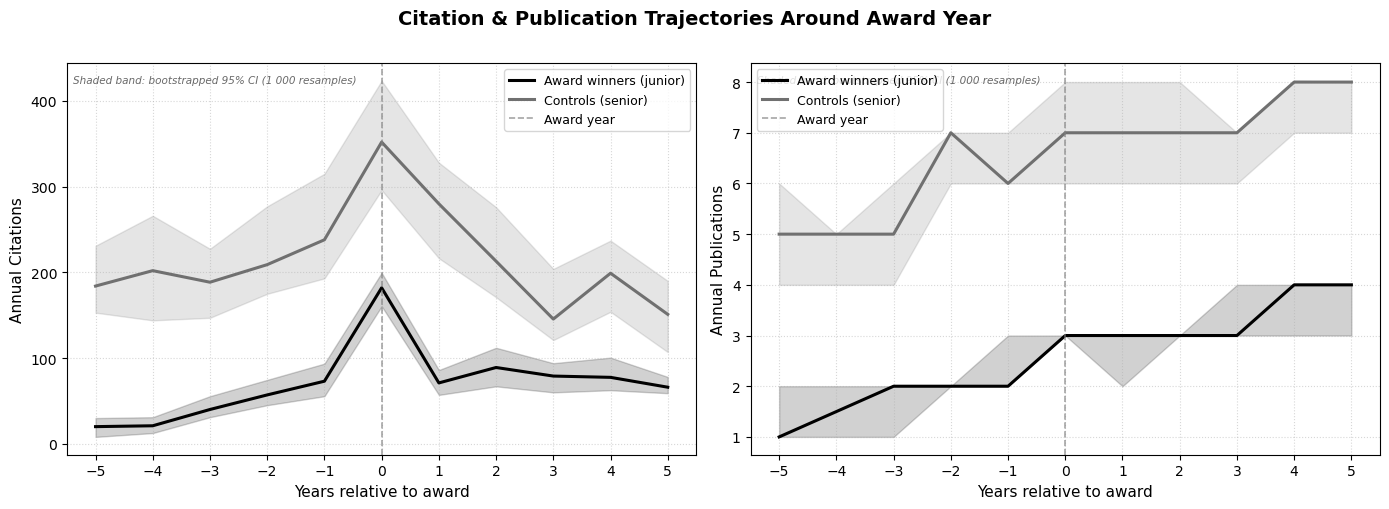

✓ Saved: 11_lift_trajectories.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def bootstrap_median_ci(data, n_boot=1000, ci=0.95, rng=None):
    """Return (lo, hi) bootstrap CI for the median of `data`."""
    if rng is None:
        rng = np.random.default_rng(42)
    arr = np.asarray(data)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan
    boot = np.median(rng.choice(arr, size=(n_boot, len(arr)), replace=True), axis=1)
    alpha = (1 - ci) / 2
    return np.percentile(boot, 100 * alpha), np.percentile(boot, 100 * (1 - alpha))


def traj_stats(df, treatment_val, metric, rel_years, n_boot=1000):
    """Median + bootstrapped 95% CI per rel_year for one group."""
    rng = np.random.default_rng(42)
    sub = df[df["treatment"] == treatment_val]
    medians, lo_ci, hi_ci = [], [], []
    for ry in rel_years:
        vals = sub.loc[sub["rel_year"] == ry, metric].dropna().values
        medians.append(np.median(vals) if len(vals) else np.nan)
        lo, hi = bootstrap_median_ci(vals, n_boot=n_boot, rng=rng)
        lo_ci.append(lo)
        hi_ci.append(hi)
    return np.array(medians), np.array(lo_ci), np.array(hi_ci)


REL_YEARS = list(range(-5, 6))
WINDOW    = long[long["rel_year"].between(-5, 5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Citation & Publication Trajectories Around Award Year",
             fontsize=14, fontweight="bold", y=1.01)

configs = [
    (axes[0], "citations", "Annual Citations"),
    (axes[1], "works",     "Annual Publications"),
]

for ax, metric, ylabel in configs:
    for treat_val, label, color in [
        (1, "Award winners (junior)",  "#000000"),
        (0, "Controls (senior)",       "#707070"),
    ]:
        med, lo, hi = traj_stats(WINDOW, treat_val, metric, REL_YEARS)
        ax.plot(REL_YEARS, med,    color=color, lw=2.2, label=label)
        ax.fill_between(REL_YEARS, lo, hi, color=color, alpha=0.18,
                        label="_nolegend_")

    ax.axvline(0, color="gray", linestyle="--", lw=1.2, alpha=0.7,
               label="Award year")
    ax.set_xlabel("Years relative to award", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.text(0.01, 0.97, "Shaded band: bootstrapped 95% CI (1 000 resamples)",
            transform=ax.transAxes, fontsize=7.5, va="top",
            color="dimgray", style="italic")

plt.tight_layout()
out_path = DATA_FIGURES / "11_lift_trajectories.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {out_path.name}")
